# concept-graph-xai — credit-risk walkthrough

Trains a LightGBM classifier on the **Give Me Some Credit** Kaggle dataset and demonstrates every plot the package ships, organised by *what question you'd ask next*, not by which release added what.

## Outline

**Part A — Setup**
1. Imports and constants
2. Load the dataset (Kaggle, with synthetic fallback)
3. Define the concept graph
4. Train LightGBM
5. Compute SHAP values

**Part B — Map the model's structure**
6. Concept utilization (which branches the model actually uses)
7. Concept importance: point estimate (sunburst) + bootstrap CIs (signed bar)

**Part C — How the signal composes**
8. SHAP interaction matrix (concept × concept)
9. SHAP flow Sankey (feature → concepts → ±outcome)

**Part D — Per-prediction explanations**
10. Concept violin — per-sample distribution of summed signed SHAP
11. Concept waterfall — single-prediction explanation rolled up to the tree

**Part E — Concept-design diagnostics**
12. Block-structured feature correlation
13. Block-structured nullity correlation
14. Joint-missing-rate sunburst
15. Concept-coherence vs concept-importance scatter
16. Block-structured SHAP correlation
17. Regulatory-tag overlay

**Part F — Cohort analysis**
18. Segment × concept importance heatmap
19. Concept-importance Pareto curves per cohort

**Part G — Fairness**
20. Concept disparity heatmap (vs reference protected group)

**Part H — Robustness & drift**
21. AUC drop per concept (permutation / SHAP-marginal / retrain ablations)
22. Multi-period drift line chart
23. Drift delta sunburst (baseline → target)

**Part I — Static PNG export**
24. Render every figure to PNG for paper / slides

## Part A — Setup

### A.1 Imports and constants

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from concept_graph_xai import (
    ConceptGraph,
    ConceptPredictionExplainer,
    auc_drop,
    auc_drop_map,
    coherence_importance,
    coherence_importance_scatter,
    bootstrap_importance,
    concept_interaction_heatmap,
    attribution_drift,
    concept_disparity,
    concept_disparity_heatmap,
    concept_drift_delta,
    concept_drift_lines,
    concept_drift_sunburst,
    concept_interaction_matrix,
    concept_pareto,
    concept_sankey,
    concept_violin,
    correlation_block,
    feature_correlation,
    feature_counts,
    importance_sum,
    joint_missing_map,
    joint_missing_rate,
    nullity_correlation,
    regulatory_tag_overlay,
    segment_concept_heatmap,
    segment_importance,
    shap_correlation,
    signed_concept_bar,
    sunburst,
    utilization,
    utilization_map,
)
from concept_graph_xai.adapters import from_shap_explanation

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### A.2 Load the dataset
We try Kaggle first via `kagglehub`; if that fails we fall back to the synthetic fixture and rename columns to the GMSC schema so the rest of the notebook stays identical.

In [2]:
GMSC_COLUMNS = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]
TARGET = "SeriousDlqin2yrs"


def load_kaggle_gmsc() -> pd.DataFrame:
    import kagglehub
    p = kagglehub.dataset_download("brycecf/give-me-some-credit-dataset")
    candidates = [f for f in os.listdir(p) if f.lower().startswith("cs-training")]
    if not candidates:
        raise FileNotFoundError(f"cs-training.csv not found in {p}")
    return pd.read_csv(os.path.join(p, candidates[0]), index_col=0)


def load_synthetic() -> pd.DataFrame:
    import sys
    repo_root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
    sys.path.insert(0, str(repo_root))
    from tests.fixtures.credit_risk_toy import make_dataset
    toy = make_dataset(n=10_000, seed=RANDOM_STATE)
    rename = {
        "revolving_utilization": "RevolvingUtilizationOfUnsecuredLines",
        "n_30_59_dpd": "NumberOfTime30-59DaysPastDueNotWorse",
        "debt_ratio": "DebtRatio",
        "monthly_income": "MonthlyIncome",
        "n_90_plus_dpd": "NumberOfTimes90DaysLate",
        "n_60_89_dpd": "NumberOfTime60-89DaysPastDueNotWorse",
        "n_dependents": "NumberOfDependents",
    }
    df = toy.X.rename(columns=rename).assign(
        NumberOfOpenCreditLinesAndLoans=lambda d: np.random.poisson(8, len(d)),
        NumberRealEstateLoansOrLines=lambda d: np.random.poisson(1.0, len(d)),
    )
    df[TARGET] = toy.y
    return df.loc[:, [TARGET, *GMSC_COLUMNS]]


try:
    df = load_kaggle_gmsc()
    source = "kaggle"
except Exception as e:
    print(f"Falling back to synthetic dataset: {type(e).__name__}: {e}")
    df = load_synthetic()
    source = "synthetic"

df = df.dropna(subset=[TARGET]).copy()
for col in GMSC_COLUMNS:
    df[col] = df[col].fillna(df[col].median())

X = df[GMSC_COLUMNS]
y = df[TARGET].astype(int).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"{source}: {len(df):,} rows, {len(GMSC_COLUMNS)} features")
print(f"train={X_train.shape}, test={X_test.shape}, prevalence={y_train.mean():.3f}")

kaggle: 150,000 rows, 10 features
train=(112500, 10), test=(37500, 10), prevalence=0.067


### A.3 Define the concept graph

The graph deliberately declares `WebActivity` (under `Behaviour`) and a top-level `AlternativeData` branch even though those columns are **not** in `X`. The `utilization_map` below will render them grey — that's how you spot concepts you *meant* to model but haven't wired up yet.

In [3]:
graph = ConceptGraph.from_dict({
    "RiskProfile": {
        "Demographics": {
            "Age": ["age"],
            "Family": ["NumberOfDependents"],
        },
        "Income": ["MonthlyIncome", "DebtRatio"],
        "Behaviour": {
            "Delinquency": [
                "NumberOfTime30-59DaysPastDueNotWorse",
                "NumberOfTime60-89DaysPastDueNotWorse",
                "NumberOfTimes90DaysLate",
            ],
            "Utilization": ["RevolvingUtilizationOfUnsecuredLines"],
            "CreditLines": [
                "NumberOfOpenCreditLinesAndLoans",
                "NumberRealEstateLoansOrLines",
            ],
            # Declared but not in X — stays grey in the utilization map.
            "WebActivity": ["web_logins_30d", "mobile_taps_30d"],
        },
        # Phantom top-level branch — declared but not modelled.
        "AlternativeData": {
            "SocialGraph": ["social_centrality"],
            "DeviceTrust": ["device_age_days"],
        },
    }
})
print(f"{len(graph.features())} features, {len(graph.concepts())} concepts")

14 features, 13 concepts


### A.4 Train LightGBM

In [4]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    verbose=-1,
)
model.fit(X_train, y_train)
p_test = model.predict_proba(X_test)[:, 1]
print(f"Hold-out AUC: {roc_auc_score(y_test, p_test):.4f}")

Hold-out AUC: 0.8672


### A.5 SHAP values

In [5]:
explainer = shap.TreeExplainer(model)
explanation = explainer(X_test)
shap_values, feature_names = from_shap_explanation(
    explanation, feature_names=X_test.columns.tolist()
)
base_value = float(np.asarray(explainer.expected_value).reshape(-1)[-1])
print(f"SHAP shape: {shap_values.shape}, base value (logit): {base_value:+.4f}")

SHAP shape: (37500, 10), base value (logit): -3.5932


## Part B — Map the model's structure
Where do the model's features sit in your concept tree, and how much does each concept matter? Two complementary views: a structural one (which branches the model actually uses) and an importance one (how much each concept drives the prediction, with bootstrap CIs around the signed mean).

### B.1 Concept utilization
Sector area = feature count per concept; used branches are coloured by family with hierarchical shading; unused branches (declared in the graph but absent from `X`) are grey. This subsumes the standalone feature-count view.

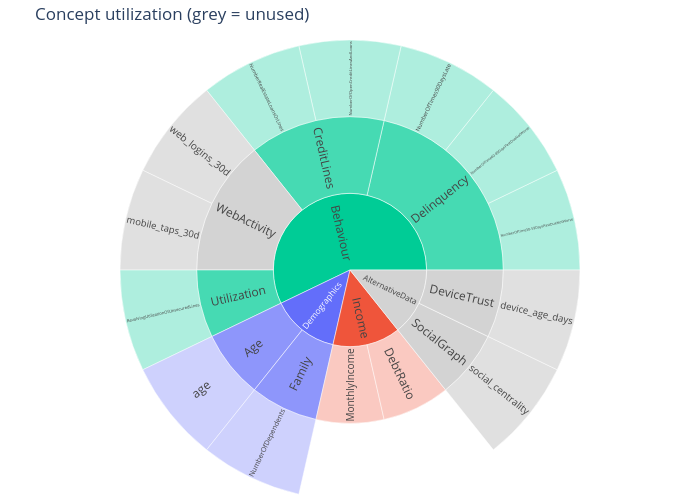

,name,kind,used_feature_count,feature_count,is_used
path,,,,,
RiskProfile,RiskProfile,concept,10,14,True
RiskProfile/Demographics,Demographics,concept,2,2,True
RiskProfile/Demographics/Age,Age,concept,1,1,True
RiskProfile/Demographics/Age/age,age,feature,1,1,True
RiskProfile/Demographics/Family,Family,concept,1,1,True
RiskProfile/Demographics/Family/NumberOfDependents,NumberOfDependents,feature,1,1,True
RiskProfile/Income,Income,concept,2,2,True
RiskProfile/Income/MonthlyIncome,MonthlyIncome,feature,1,1,True
RiskProfile/Income/DebtRatio,DebtRatio,feature,1,1,True


In [6]:
util_df = utilization(graph, feature_names, shap_values, threshold=0.0)
fig_util = utilization_map(graph, util_df, title="Concept utilization (grey = unused)")
fig_util.show()
util_df[["name", "kind", "used_feature_count", "feature_count", "is_used"]]

### B.2 Concept importance — point estimate + bootstrap CIs
Two complementary views on the same SHAP values. The **sunburst** shows magnitude (mean `|SHAP|`) per concept — the standard "which concept matters?" view. The **bar chart** adds signed direction (mean SHAP can cancel across samples) and 95% bootstrap CIs (resampling the held-out rows tells you how stable each estimate is).

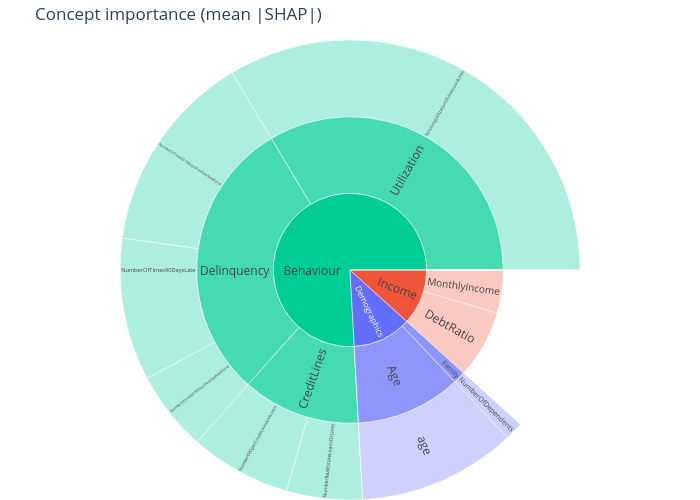

In [7]:
imp_df = importance_sum(graph, feature_names, shap_values)
# No colorscale → sunburst() colours by top-level branch (each branch gets one hue).
fig_imp = sunburst(graph, imp_df, value="importance_sum",
                   title="Concept importance (mean |SHAP|)")
fig_imp.show()

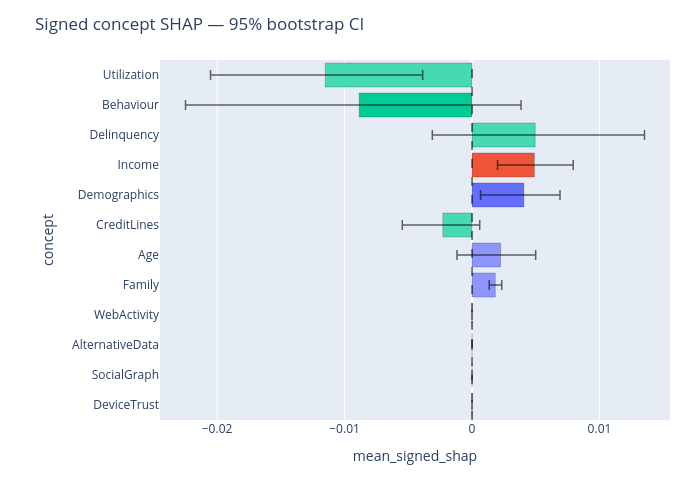

,name,mean_signed_shap,ci_lo,ci_hi,feature_count
path,,,,,
RiskProfile,RiskProfile,0.000104,-0.014590,0.014168,10
RiskProfile/Demographics,Demographics,0.004065,0.000668,0.006901,2
RiskProfile/Demographics/Age,Age,0.002239,-0.001180,0.004993,1
RiskProfile/Demographics/Family,Family,0.001826,0.001343,0.002323,1
RiskProfile/Income,Income,0.004890,0.001999,0.007936,2
RiskProfile/Behaviour,Behaviour,-0.008851,-0.022477,0.003846,6
RiskProfile/Behaviour/Delinquency,Delinquency,0.004954,-0.003115,0.013529,3
RiskProfile/Behaviour/Utilization,Utilization,-0.011514,-0.020513,-0.003872,1
RiskProfile/Behaviour/CreditLines,CreditLines,-0.002291,-0.005471,0.000603,2


In [8]:
boot_df = bootstrap_importance(
    graph, feature_names, shap_values,
    n_bootstrap=300, ci=0.95, random_state=RANDOM_STATE,
)
fig_bootstrap_bar = signed_concept_bar(graph, boot_df,
                                       title="Signed concept SHAP — 95% bootstrap CI")
fig_bootstrap_bar.show()
boot_df.loc[boot_df["kind"] == "concept", ["name", "mean_signed_shap", "ci_lo", "ci_hi", "feature_count"]]

## Part C — How the signal composes
Per-feature SHAP collapses interactions into single-feature attributions. Two views recover the missing structure: a concept × concept **interaction matrix** (using SHAP interaction values), and a **flow Sankey** that traces SHAP magnitude from features through every concept tier to the +/- outcome.

### C.1 SHAP interaction matrix (concept × concept)
Needs the full SHAP **interaction tensor** — `(N, F, F)` per-sample interaction effects between every feature pair. This is heavy (TreeExplainer-only, O(F²) per sample) so we compute it once here, not at the top with the regular SHAP values.

In [9]:
# Heavy: TreeExplainer interaction values, shape (N, F, F).
# Subsample X_test to keep runtime sane on the full Kaggle set.
interaction_sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
shap_interaction_values = explainer.shap_interaction_values(interaction_sample)
print(f"interaction tensor: {shap_interaction_values.shape}")

interaction tensor: (2000, 10, 10)


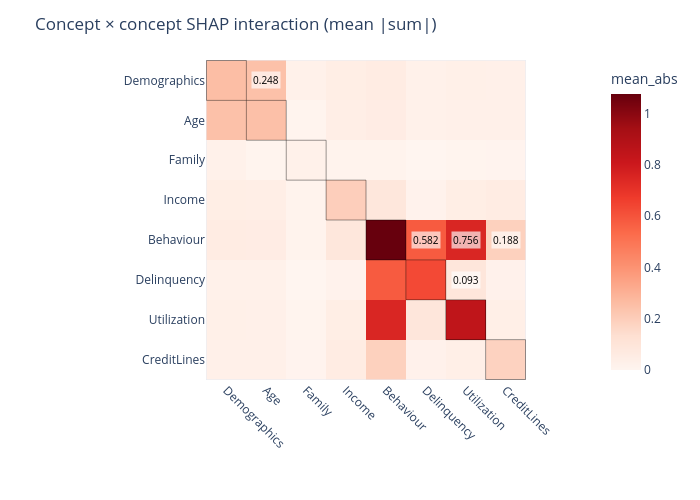

,Demographics,Age,Family,Income,Behaviour,Delinquency,Utilization,CreditLines
Demographics,0.259405,0.247648,0.027113,0.047671,0.060108,0.026031,0.035260,0.033392
Age,0.247648,0.250059,0.008464,0.043756,0.054743,0.025635,0.032512,0.029347
Family,0.027113,0.008464,0.028590,0.013474,0.013278,0.002160,0.007993,0.009640
Income,0.047671,0.043756,0.013474,0.198561,0.088488,0.016557,0.047501,0.056483
Behaviour,0.060108,0.054743,0.013278,0.088488,1.077059,0.582126,0.755707,0.188465
Delinquency,0.026031,0.025635,0.002160,0.016557,0.582126,0.632612,0.093414,0.022989
Utilization,0.035260,0.032512,0.007993,0.047501,0.755707,0.093414,0.851029,0.039878
CreditLines,0.033392,0.029347,0.009640,0.056483,0.188465,0.022989,0.039878,0.185342


In [10]:
interaction_df = concept_interaction_matrix(
    graph, list(interaction_sample.columns), shap_interaction_values,
)
fig_interaction = concept_interaction_heatmap(
    interaction_df,
    title="Concept × concept SHAP interaction (mean |sum|)",
    annotate_top_k=5,
)
fig_interaction.show()
interaction_df

### C.2 SHAP flow — feature → concepts → ±outcome
A multi-tier Sankey: each feature on the left, then every concept on its ancestor chain (sub-concepts in the middle, top-level on the right), then the +/- outcome. Link width is SHAP magnitude. At every concept node, incoming flow can exceed outgoing — that shrinkage is within-concept cancellation (some samples push positive, others push negative).

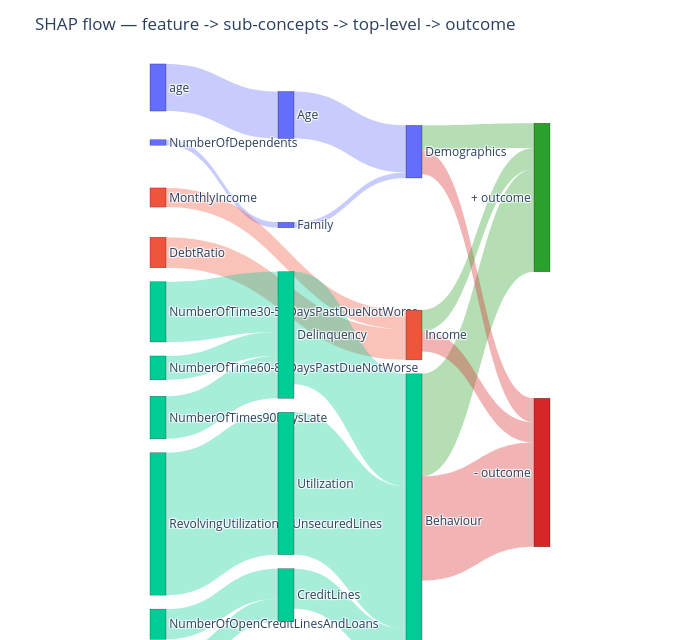

In [11]:
fig_sankey = concept_sankey(
    graph, feature_names, shap_values,
    title="SHAP flow — feature -> sub-concepts -> top-level -> outcome",
)
fig_sankey.show()

## Part D — Per-prediction explanations
Global plots tell you what the model does on average. The plots in this section explain *individual* predictions and the per-sample distribution of effects.

### D.1 Concept violin
For each concept, a horizontal violin (KDE) of the summed signed SHAP across the held-out set. The violin width at each x is the density of samples with that contribution; a violin that bulges to the right of the dashed line consistently raises the predicted probability, one centred on zero is sometimes risk-increasing and sometimes risk-decreasing.

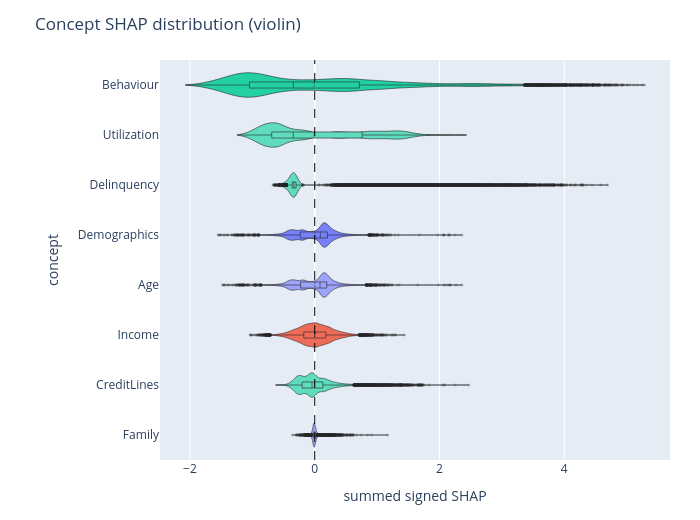

In [12]:
fig_violin = concept_violin(
    graph, feature_names, shap_values,
    only_concepts=True,
    title="Concept SHAP distribution (violin)",
)
fig_violin.show()

### D.2 Concept waterfall — single-prediction explanation
`ConceptPredictionExplainer` rolls up the per-sample SHAP into the supplied tree. Pick any row in `X_test`; the waterfall starts at the SHAP base value (model's expected logit), applies each concept's contribution in descending magnitude, and ends at the predicted logit.

In [13]:
predictor = ConceptPredictionExplainer(
    graph, model=model, X=X_test,
    shap_values=shap_values,
    base_value=base_value,
)

# Pick the highest- and lowest-risk samples to contrast
high_risk_idx = int(np.argmax(p_test))
low_risk_idx = int(np.argmin(p_test))
print(f"highest-risk row: {high_risk_idx}, P(y=1)={p_test[high_risk_idx]:.4f}")
print(f"lowest-risk  row: {low_risk_idx},  P(y=1)={p_test[low_risk_idx]:.4f}")

highest-risk row: 21750, P(y=1)=0.8565
lowest-risk  row: 11010,  P(y=1)=0.0005


#### D.2a Highest-risk prediction

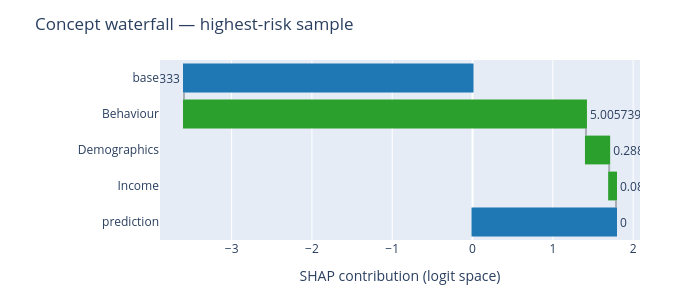

,name,path,depth,feature_count,shap_sum
0,Behaviour,RiskProfile/Behaviour,1,6,5.005739
1,Demographics,RiskProfile/Demographics,1,2,0.288832
2,Income,RiskProfile/Income,1,2,0.085304


In [14]:
fig_high = predictor.waterfall(high_risk_idx, depth=1,
                                title="Concept waterfall — highest-risk sample")
fig_high.show()
predictor.breakdown(high_risk_idx, depth=1)

#### D.2b Lowest-risk prediction

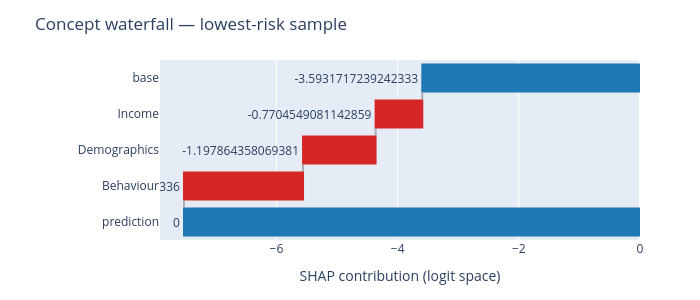

,name,path,depth,feature_count,shap_sum
0,Income,RiskProfile/Income,1,2,-0.770455
1,Demographics,RiskProfile/Demographics,1,2,-1.197864
2,Behaviour,RiskProfile/Behaviour,1,6,-1.964379


In [15]:
fig_low = predictor.waterfall(low_risk_idx, depth=1,
                               title="Concept waterfall — lowest-risk sample")
fig_low.show()
predictor.breakdown(low_risk_idx, depth=1)

#### D.2c Drill into the Behaviour sub-tree (depth=2)
The same prediction at a deeper level — Behaviour splits into Delinquency, Utilization, CreditLines, and Demographics splits into Age and Family. Useful when a top-level concept is the dominant driver.

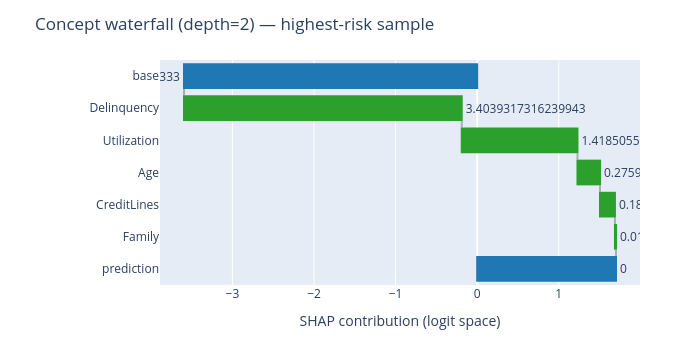

In [16]:
fig_high_d2 = predictor.waterfall(high_risk_idx, depth=2,
                                   title="Concept waterfall (depth=2) — highest-risk sample")
fig_high_d2.show()

## Part E — Concept-design diagnostics
Is your concept tree itself well-designed, or are you grouping unrelated features under one label? Block correlations, joint missingness, and the coherence-vs-importance scatter answer this without involving the model.

In [17]:
# Re-introduce missingness for the §C demo (the cleaned X has none).
X_with_missing = X_test.copy()
rng = np.random.default_rng(RANDOM_STATE)
rows = rng.choice(len(X_with_missing), size=int(len(X_with_missing) * 0.05), replace=False)
X_with_missing.loc[X_with_missing.index[rows], ["MonthlyIncome", "DebtRatio"]] = np.nan
rows2 = rng.choice(len(X_with_missing), size=int(len(X_with_missing) * 0.02), replace=False)
X_with_missing.loc[X_with_missing.index[rows2], "NumberOfDependents"] = np.nan

### E.1 Block-structured feature correlation
Diagonal blocks reveal within-concept coherence; off-diagonal blocks reveal boundary leakage (features in different concepts that turn out to be highly correlated).

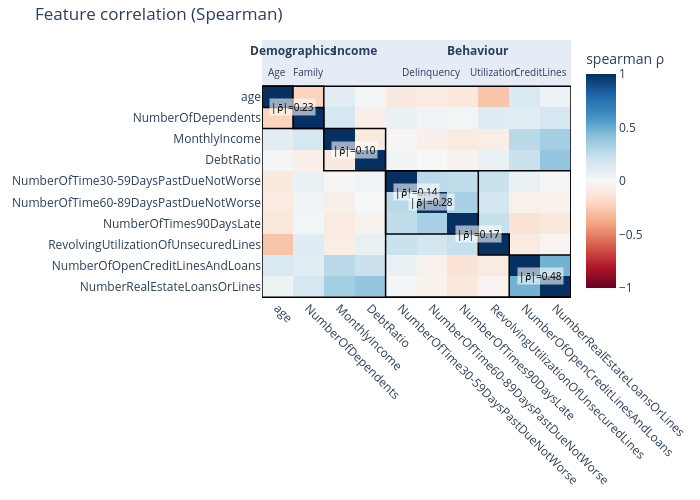

,concept_path,size,mean_abs,median_abs,min,max
8,RiskProfile/Behaviour/CreditLines,2,0.476661,0.476661,0.476661,0.476661
6,RiskProfile/Behaviour/Delinquency,3,0.283006,0.271860,0.250599,0.326558
1,RiskProfile/Demographics,2,0.231077,0.231077,-0.231077,-0.231077
5,RiskProfile/Behaviour,6,0.167463,0.142557,-0.142557,0.476661
0,RiskProfile,10,0.137059,0.100126,-0.282715,0.476661
4,RiskProfile/Income,2,0.100126,0.100126,-0.100126,-0.100126
2,RiskProfile/Demographics/Age,1,NaN,NaN,NaN,NaN
3,RiskProfile/Demographics/Family,1,NaN,NaN,NaN,NaN
7,RiskProfile/Behaviour/Utilization,1,NaN,NaN,NaN,NaN


In [18]:
feat_corr = feature_correlation(graph, X_test, method="spearman")
fig_feat_corr = correlation_block(feat_corr, title="Feature correlation (Spearman)")
fig_feat_corr.show()
feat_corr.block_stats.sort_values("mean_abs", ascending=False)

### E.2 Block-structured nullity correlation
Same heatmap, but on `X.isna()` instead of `X`. A bright diagonal block means the features in that concept tend to go missing together.

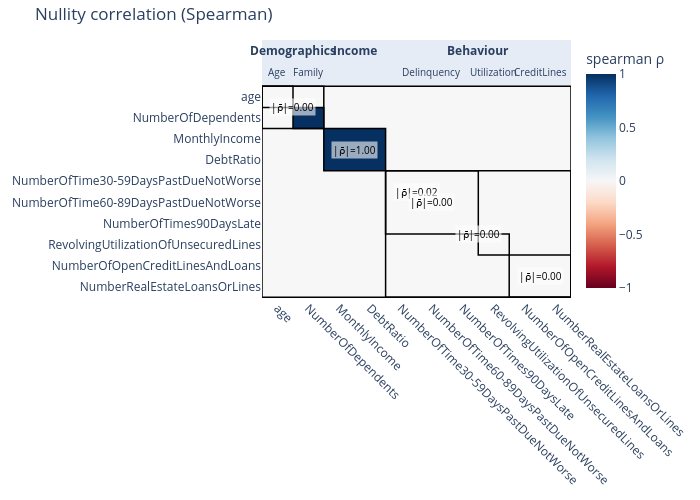

,concept_path,size,mean_abs,median_abs,min,max
4,RiskProfile/Income,2,1.000000,1.0,1.000000,1.0
0,RiskProfile,10,0.022242,0.0,-0.000437,1.0
1,RiskProfile/Demographics,2,0.000000,0.0,0.000000,0.0
5,RiskProfile/Behaviour,6,0.000000,0.0,0.000000,0.0
6,RiskProfile/Behaviour/Delinquency,3,0.000000,0.0,0.000000,0.0
8,RiskProfile/Behaviour/CreditLines,2,0.000000,0.0,0.000000,0.0
2,RiskProfile/Demographics/Age,1,NaN,NaN,NaN,NaN
3,RiskProfile/Demographics/Family,1,NaN,NaN,NaN,NaN
7,RiskProfile/Behaviour/Utilization,1,NaN,NaN,NaN,NaN


In [19]:
null_corr = nullity_correlation(graph, X_with_missing)
fig_null_corr = correlation_block(null_corr, title="Nullity correlation (Spearman)")
fig_null_corr.show()
null_corr.block_stats.sort_values("mean_abs", ascending=False)

### E.3 Joint-missing-rate sunburst
How often does the *whole branch* go missing at once? Sector colour intensity = `mean(all features under concept are NaN)`. Drives the "is the AUC-drop scenario realistic?" judgement.

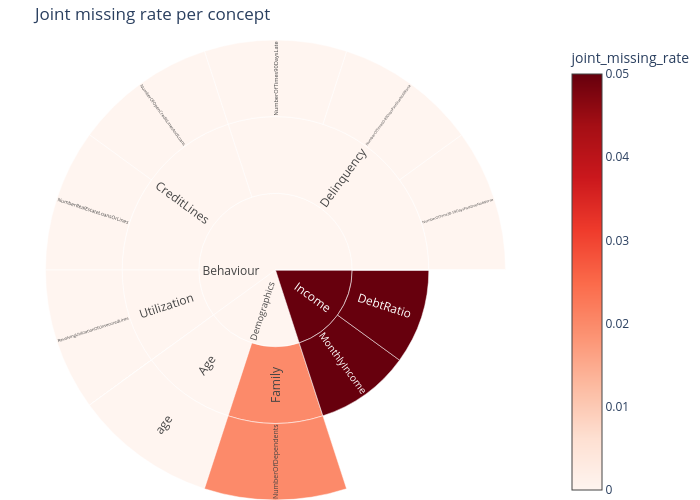

,name,feature_count,joint_missing_rate
path,,,
RiskProfile/Income,Income,2,0.05
RiskProfile/Demographics/Family,Family,1,0.02
RiskProfile,RiskProfile,10,0.00
RiskProfile/Demographics/Age,Age,1,0.00
RiskProfile/Demographics,Demographics,2,0.00
RiskProfile/Behaviour,Behaviour,6,0.00
RiskProfile/Behaviour/Delinquency,Delinquency,3,0.00
RiskProfile/Behaviour/Utilization,Utilization,1,0.00
RiskProfile/Behaviour/CreditLines,CreditLines,2,0.00


In [20]:
jmr_df = joint_missing_rate(graph, X_with_missing)
fig_jmr = joint_missing_map(graph, jmr_df, title="Joint missing rate per concept")
fig_jmr.show()
jmr_df.loc[jmr_df["kind"] == "concept", ["name", "feature_count", "joint_missing_rate"]].sort_values("joint_missing_rate", ascending=False)

### E.4 Concept-coherence vs concept-importance scatter
Headline diagnostic. **Green** = well-designed; **red** = kitchen sink (split it); **orange** = redundant; **grey** = noise.

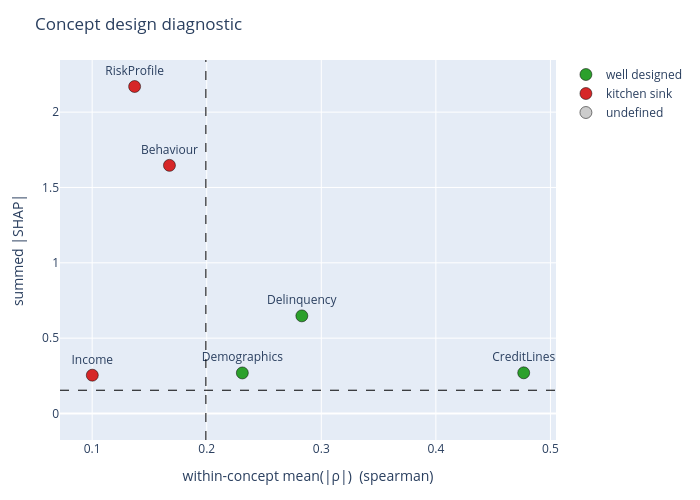

,name,coherence,importance_sum,quadrant
path,,,,
RiskProfile,RiskProfile,0.137059,2.170146,kitchen_sink
RiskProfile/Demographics,Demographics,0.231077,0.269232,well_designed
RiskProfile/Demographics/Age,Age,NaN,0.241114,undefined
RiskProfile/Demographics/Family,Family,NaN,0.028118,undefined
RiskProfile/Income,Income,0.100126,0.254168,kitchen_sink
RiskProfile/Behaviour,Behaviour,0.167463,1.646746,kitchen_sink
RiskProfile/Behaviour/Delinquency,Delinquency,0.283006,0.647927,well_designed
RiskProfile/Behaviour/Utilization,Utilization,NaN,0.728765,undefined
RiskProfile/Behaviour/CreditLines,CreditLines,0.476661,0.270054,well_designed


In [21]:
coh_df = coherence_importance(graph, X_test, feature_names, shap_values)
fig_coh = coherence_importance_scatter(coh_df, title="Concept design diagnostic")
fig_coh.show()
coh_df.loc[coh_df["kind"] == "concept", ["name", "coherence", "importance_sum", "quadrant"]]

### E.5 Block-structured SHAP correlation
Two raw-uncorrelated features can still be SHAP-redundant. Diagonal blocks near 1 indicate features inside a concept push the model in the same way; off-diagonal blocks near 1 indicate the model treats different concepts as substitutes.

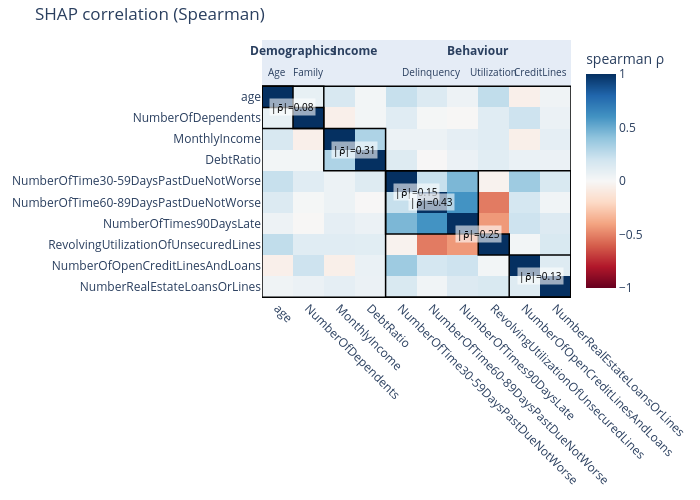

,concept_path,size,mean_abs,median_abs,min,max
6,RiskProfile/Behaviour/Delinquency,3,0.430048,0.456924,0.231913,0.601309
4,RiskProfile/Income,2,0.312633,0.312633,0.312633,0.312633
5,RiskProfile/Behaviour,6,0.245600,0.178532,-0.521979,0.601309
0,RiskProfile,10,0.146513,0.114979,-0.521979,0.601309
8,RiskProfile/Behaviour/CreditLines,2,0.128974,0.128974,0.128974,0.128974
1,RiskProfile/Demographics,2,0.081673,0.081673,0.081673,0.081673
2,RiskProfile/Demographics/Age,1,NaN,NaN,NaN,NaN
3,RiskProfile/Demographics/Family,1,NaN,NaN,NaN,NaN
7,RiskProfile/Behaviour/Utilization,1,NaN,NaN,NaN,NaN


In [22]:
shap_corr = shap_correlation(graph, feature_names, shap_values, method="spearman")
fig_shap_corr = correlation_block(shap_corr, title="SHAP correlation (Spearman)")
fig_shap_corr.show()
shap_corr.block_stats.sort_values("mean_abs", ascending=False)

### E.6 Regulatory-tag overlay
How much of the model's decision flows through PII / financial / behavioural concepts? Sector colour comes from the node metadata.

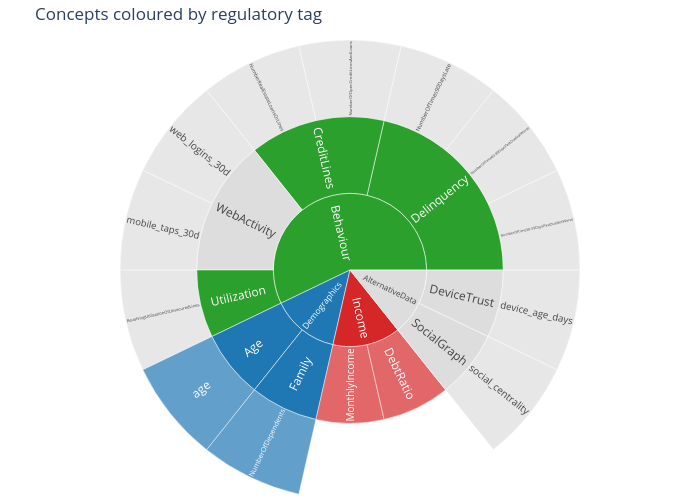

In [23]:
import networkx as nx
g = graph.graph.copy()
tag_map = {
    "Demographics": "PII", "Age": "PII", "Family": "PII",
    "NumberOfDependents": "PII", "age": "PII",
    "Income": "financial", "MonthlyIncome": "financial", "DebtRatio": "financial",
    "Behaviour": "behavioural", "Delinquency": "behavioural",
    "Utilization": "behavioural", "CreditLines": "behavioural",
}
for node, tag in tag_map.items():
    if node in g.nodes:
        g.nodes[node]["metadata"] = {"tag": tag}
tagged_graph = ConceptGraph.from_networkx(g, root=graph.root)
fig_tag = regulatory_tag_overlay(tagged_graph, title="Concepts coloured by regulatory tag")
fig_tag.show()

## Part F — Cohort analysis
Global SHAP averages can mask cohort-level differences. The Income concept might be a dominant driver for high-income applicants and irrelevant for low-income ones — averaged, it looks like a moderate driver across the board. Part F splits the held-out set into cohorts and inspects how each concept's importance varies.

GMSC doesn't ship cohort labels, so we synthesise four age bands as a stand-in. Any pandas Series aligned to `X_test` (or a column name referencing it) works as a cohort vector.

In [24]:
age_cohort = pd.cut(
    X_test["age"],
    bins=[0, 30, 50, 65, 200],
    labels=["<30", "30-50", "50-65", "65+"],
    right=False,
)
age_cohort.value_counts(sort=False)

age
<30       2165
30-50    14379
50-65    13052
65+       7904
Name: count, dtype: int64

### F.1 Segment × concept importance heatmap
For each age cohort, the mean magnitude of summed signed SHAP per concept. Higher (darker) = the concept matters more to this cohort's predictions. Watch for concepts that swing strongly across cohorts — those are where the model uses different signal for different segments.

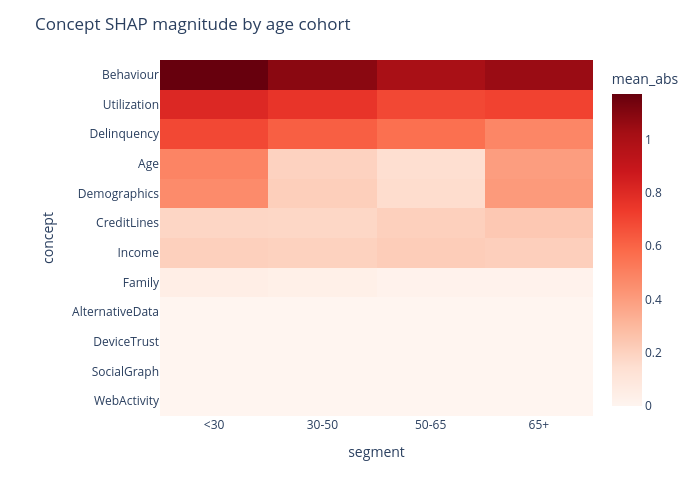

segment,30-50,50-65,65+,<30
name,,,,
Age,0.200008,0.149506,0.398822,0.490635
AlternativeData,0.000000,0.000000,0.000000,0.000000
Behaviour,1.089530,1.008919,1.050899,1.171396
CreditLines,0.183505,0.209689,0.239683,0.186095
Delinquency,0.619016,0.563113,0.484846,0.691672
Demographics,0.214806,0.157425,0.410928,0.465893
DeviceTrust,0.000000,0.000000,0.000000,0.000000
Family,0.037044,0.020895,0.018417,0.047793
Income,0.203225,0.220954,0.213478,0.209644


In [25]:
segment_df = segment_importance(
    graph, feature_names, shap_values,
    age_cohort.reset_index(drop=True),
    agg="mean_abs",
)
fig_segment_heatmap = segment_concept_heatmap(
    graph, segment_df,
    title="Concept SHAP magnitude by age cohort",
)
fig_segment_heatmap.show()
segment_df.loc[segment_df["kind"] == "concept", ["name", "segment", "value"]].pivot(index="name", columns="segment", values="value")

### F.2 Concept-importance Pareto curves per cohort
Reuses the `segment_df` from F.1. For each cohort, concepts are ranked by SHAP magnitude and accumulated into a Lorenz curve (cumulative share of importance vs cumulative share of concepts). A curve hugging the dashed 45° line means the model spreads its attention evenly across concepts; a curve bulging up-left means a small number of concepts dominate that cohort's predictions — concentration risk.

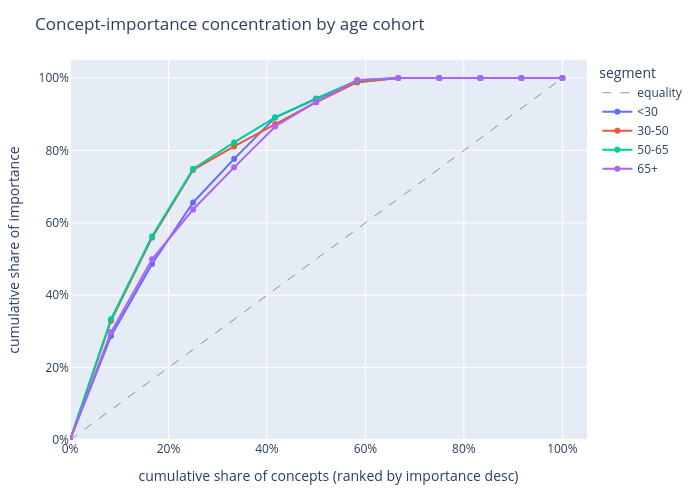

In [26]:
fig_pareto = concept_pareto(
    graph, segment_df,
    title="Concept-importance concentration by age cohort",
)
fig_pareto.show()

## Part G — Fairness
Does the model rely on the same concepts equally across protected groups? `concept_disparity` aggregates per-concept SHAP by a protected attribute and reports each group's **gap** vs a reference group (additive: `value_group - value_reference`).

GMSC doesn't ship a real protected attribute, so we synthesise one from `age`: borrowers >= 65 are `senior` and the rest are `non_senior` (the reference). Positive gap (red) = the model relies on this concept more for seniors than for the non-senior baseline; negative (blue) = less.

In [27]:
age_bracket = pd.Series(
    np.where(X_test["age"] >= 65, "senior", "non_senior"),
    index=X_test.index,
    name="age_bracket",
)
age_bracket.value_counts()

age_bracket
non_senior    29596
senior         7904
Name: count, dtype: int64

### G.1 Concept disparity heatmap (senior vs non_senior)
Reference column (`non_senior`) is exactly zero — the visible baseline. Other columns carry signed gaps. Concepts are ranked by max(|gap|) so the most age-discriminating concepts surface at the top.

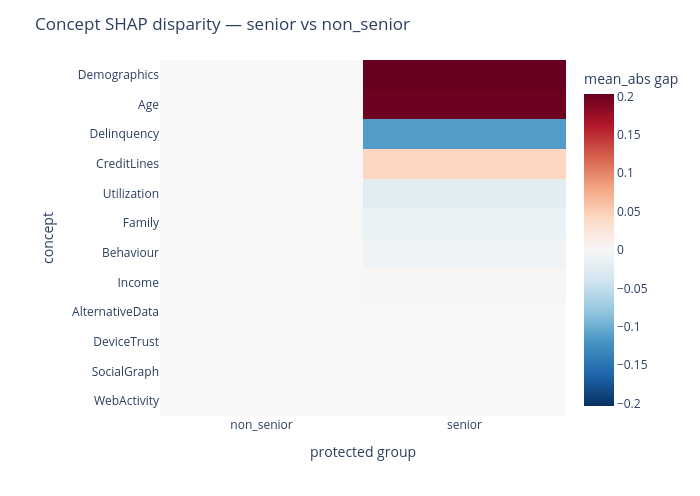

,name,protected_group,value,reference_value,feature_count
28,Demographics,senior,0.203060,0.207868,2
29,Age,senior,0.199826,0.198996,1
27,RiskProfile,senior,0.175050,1.136805,10
37,Delinquency,senior,-0.114831,0.599677,3
43,CreditLines,senior,0.044442,0.195241,2
41,Utilization,senior,-0.022270,0.733459,1
31,Family,senior,-0.012292,0.030708,1
36,Behaviour,senior,-0.009069,1.059969,6
33,Income,senior,0.001964,0.211513,2
46,WebActivity,senior,0.000000,0.000000,0


In [28]:
disparity_df = concept_disparity(
    graph, feature_names, shap_values,
    age_bracket.reset_index(drop=True),
    reference="non_senior",
    agg="mean_abs",
)
fig_disparity = concept_disparity_heatmap(
    graph, disparity_df,
    title="Concept SHAP disparity — senior vs non_senior",
)
fig_disparity.show()
disparity_df.loc[
    (disparity_df["kind"] == "concept") & (disparity_df["protected_group"] != "non_senior"),
    ["name", "protected_group", "value", "reference_value", "feature_count"],
].sort_values("value", key=abs, ascending=False)

## Part H — Robustness & drift
Two related questions: *what if a concept's data is missing or wrong* (H.1 — ablation) and *what if the input distribution shifts over time* (H.2-3 — drift).

### H.1 AUC drop per concept (ablation)
Three strategies for the same question: "how much AUC do I lose if this concept's data goes missing?". Permutation is cheap and model-agnostic; SHAP-marginal is cheapest (approximation under SHAP additivity); retrain is most faithful but expensive. Side-by-side table at the end.

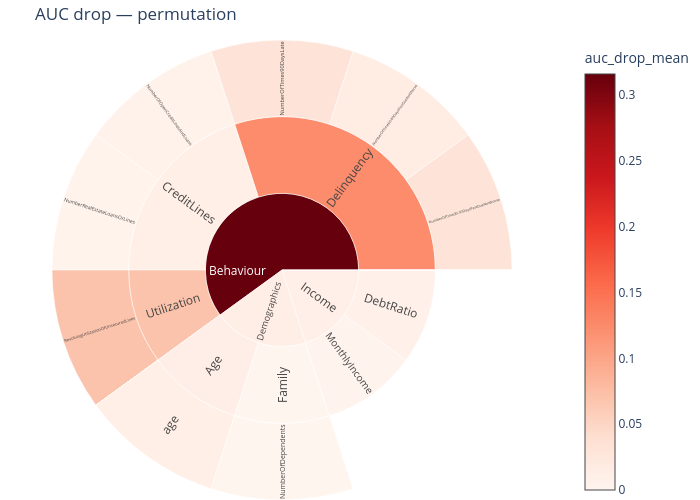

In [29]:
drop_perm = auc_drop(
    graph, model, X_test, y_test,
    feature_names=X_test.columns.tolist(),
    strategy="permutation", n_repeats=10, random_state=RANDOM_STATE,
)
fig_drop_perm = auc_drop_map(graph, drop_perm, title="AUC drop — permutation")
fig_drop_perm.show()

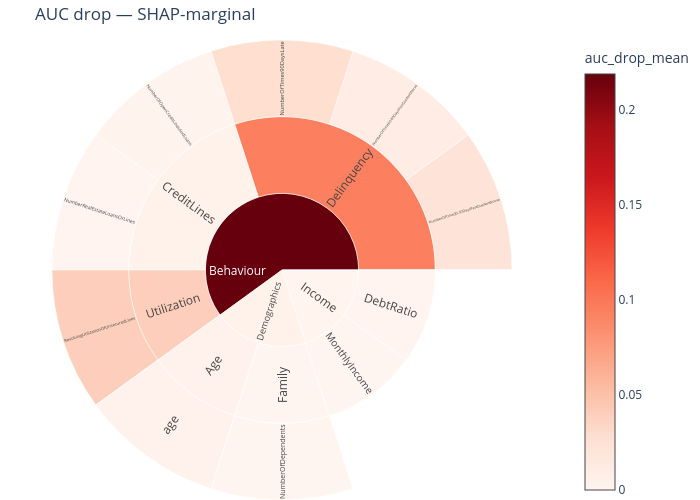

In [30]:
drop_shap = auc_drop(
    graph, model, X_test, y_test,
    feature_names=X_test.columns.tolist(),
    strategy="shap_marginal",
    shap_values=shap_values, base_predictions=p_test,
)
fig_drop_shap = auc_drop_map(graph, drop_shap, title="AUC drop — SHAP-marginal")
fig_drop_shap.show()

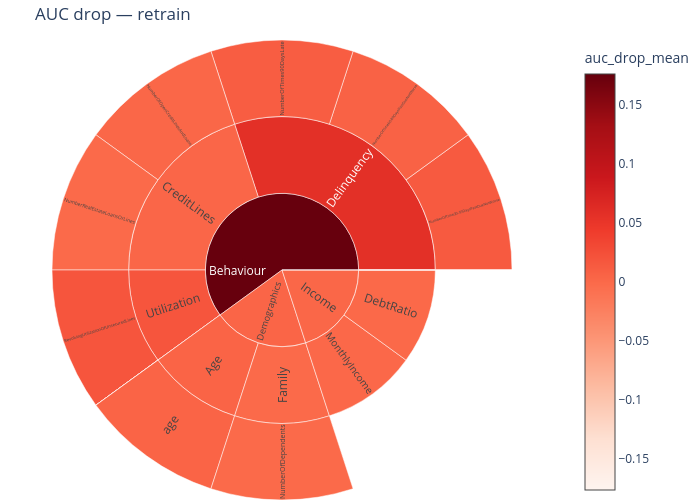

In [31]:
def train_lgb(X, y):
    m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                           num_leaves=31, random_state=RANDOM_STATE, verbose=-1)
    m.fit(X, y)
    return m

drop_retrain = auc_drop(
    graph, model, X_test, y_test,
    feature_names=X_test.columns.tolist(),
    strategy="retrain", train_fn=train_lgb,
    X_train=X_train, y_train=y_train,
)
fig_drop_retrain = auc_drop_map(graph, drop_retrain, title="AUC drop — retrain")
fig_drop_retrain.show()

In [32]:
compare = (
    drop_perm.loc[drop_perm["kind"] == "concept", ["name", "feature_count", "auc_drop_mean"]]
        .rename(columns={"auc_drop_mean": "permutation"})
        .merge(drop_shap.loc[drop_shap["kind"] == "concept", ["name", "auc_drop_mean"]]
                   .rename(columns={"auc_drop_mean": "shap_marginal"}), on="name")
        .merge(drop_retrain.loc[drop_retrain["kind"] == "concept", ["name", "auc_drop_mean"]]
                   .rename(columns={"auc_drop_mean": "retrain"}), on="name")
        .sort_values("permutation", ascending=False)
)
compare

,name,feature_count,permutation,shap_marginal,retrain
5,Behaviour,6,0.316162,0.218804,0.176429
6,Delinquency,3,0.124638,0.094274,0.058266
7,Utilization,1,0.069995,0.040312,0.019239
1,Demographics,2,0.013314,0.004172,0.004824
2,Age,1,0.012358,0.003988,0.005271
8,CreditLines,2,0.011478,0.004204,0.003539
4,Income,2,0.010921,0.001678,0.002831
3,Family,1,0.000729,0.000100,0.000276
0,RiskProfile,10,NaN,NaN,NaN
9,WebActivity,0,NaN,NaN,NaN


### H.2 Multi-period drift line chart
A production model's SHAP attributions drift as input distributions shift. We synthesise three periods by random-shuffling `X_test` into three disjoint shards. To make the drift visible, we inject `NaN` into `MonthlyIncome` for `period_3` — LightGBM handles NaN natively as a learned split, so the SHAP attribution for Income should shift in `period_3`.

In [33]:
rng_drift = np.random.default_rng(RANDOM_STATE)
shuffled_idx = rng_drift.permutation(len(X_test))
shard_size = len(X_test) // 3
period_shards = {
    "period_1": X_test.iloc[shuffled_idx[:shard_size]],
    "period_2": X_test.iloc[shuffled_idx[shard_size:2 * shard_size]],
    "period_3": X_test.iloc[shuffled_idx[2 * shard_size:]].copy(),
}
# Inject NaN into MonthlyIncome for period_3 -- simulates an upstream feed failure.
period_shards["period_3"]["MonthlyIncome"] = np.nan

periods = []
for label, shard in period_shards.items():
    shap_shard = explainer(shard).values
    periods.append((label, shap_shard, list(shard.columns)))

print({label: shard.shape for label, shard in period_shards.items()})

{'period_1': (12500, 10), 'period_2': (12500, 10), 'period_3': (12500, 10)}


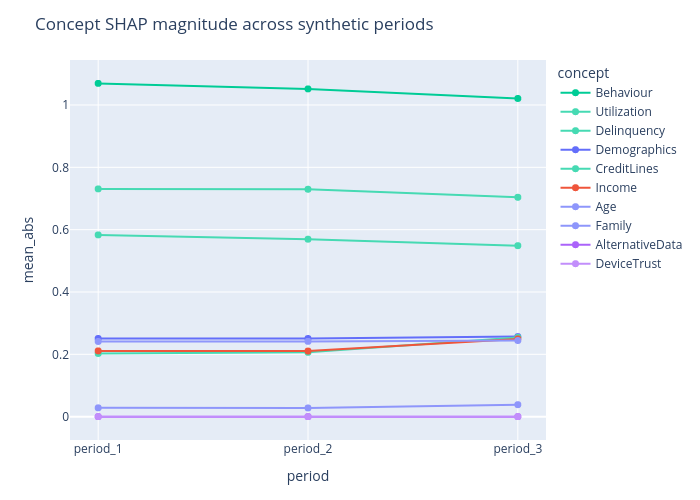

period,period_1,period_2,period_3
name,,,
Age,0.241203,0.241419,0.244254
AlternativeData,0.000000,0.000000,0.000000
Behaviour,1.069395,1.051630,1.020957
CreditLines,0.202660,0.206245,0.254115
Delinquency,0.583145,0.569329,0.548564
Demographics,0.250742,0.250710,0.256887
DeviceTrust,0.000000,0.000000,0.000000
Family,0.028209,0.027796,0.038376
Income,0.210957,0.210428,0.249419


In [34]:
drift_df = attribution_drift(graph, periods, agg="mean_abs")
fig_drift_lines = concept_drift_lines(
    graph, drift_df,
    max_concepts=10,
    title="Concept SHAP magnitude across synthetic periods",
)
fig_drift_lines.show()
drift_df.loc[drift_df["kind"] == "concept", ["name", "period", "value"]].pivot(index="name", columns="period", values="value")

### H.3 Drift delta sunburst (baseline -> target)
The drift line chart shows trajectories over time; the delta sunburst answers the simpler question "between baseline and target, which concepts changed?". Sector area encodes feature count (so the chart stays readable under the standard sunburst sum-of-children invariant); sector colour encodes `delta = target - baseline` with a diverging palette — red = importance grew between periods, blue = importance shrank.

With the `NaN`-injection in `period_3`, the Income subtree should turn the most red (its SHAP shifted under the missing-data signal).

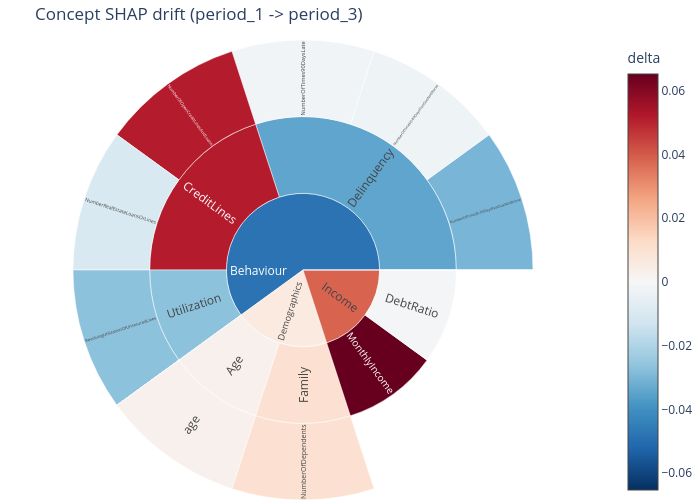

,name,baseline,target,delta,feature_count
path,,,,,
RiskProfile,RiskProfile,1.185906,1.101869,-0.084036,10
RiskProfile/Behaviour/CreditLines,CreditLines,0.202660,0.254115,0.051455,2
RiskProfile/Behaviour,Behaviour,1.069395,1.020957,-0.048438,6
RiskProfile/Income,Income,0.210957,0.249419,0.038462,2
RiskProfile/Behaviour/Delinquency,Delinquency,0.583145,0.548564,-0.034581,3
RiskProfile/Behaviour/Utilization,Utilization,0.730753,0.703837,-0.026916,1
RiskProfile/Demographics/Family,Family,0.028209,0.038376,0.010166,1
RiskProfile/Demographics,Demographics,0.250742,0.256887,0.006145,2
RiskProfile/Demographics/Age,Age,0.241203,0.244254,0.003051,1


In [35]:
drift_delta_df = concept_drift_delta(graph, periods, baseline="period_1", target="period_3")
fig_drift_sunburst = concept_drift_sunburst(
    graph, drift_delta_df,
    title="Concept SHAP drift (period_1 -> period_3)",
)
fig_drift_sunburst.show()
drift_delta_df.loc[drift_delta_df["kind"] == "concept", ["name", "baseline", "target", "delta", "feature_count"]].sort_values("delta", key=abs, ascending=False)

## Part I — Static PNG export
Render every figure to PNG for paper / slides. Requires the `[png]` extra (`uv add 'concept-graph-xai[png]'`).

In [36]:
out_dir = Path("out")
out_dir.mkdir(exist_ok=True)
exports = [
    ("importance", fig_imp),
    ("utilization", fig_util),
    ("auc_drop_permutation", fig_drop_perm),
    ("auc_drop_shap_marginal", fig_drop_shap),
    ("auc_drop_retrain", fig_drop_retrain),
    ("feature_correlation", fig_feat_corr),
    ("nullity_correlation", fig_null_corr),
    ("joint_missing", fig_jmr),
    ("coherence_importance", fig_coh),
    ("shap_correlation", fig_shap_corr),
    ("regulatory_tag", fig_tag),
    ("violin", fig_violin),
    ("waterfall_high", fig_high),
    ("waterfall_low", fig_low),
    ("waterfall_high_d2", fig_high_d2),
    ("bootstrap_bar", fig_bootstrap_bar),
    ("interaction_matrix", fig_interaction),
    ("sankey", fig_sankey),
    ("segment_heatmap", fig_segment_heatmap),
    ("pareto", fig_pareto),
    ("drift_lines", fig_drift_lines),
    ("drift_sunburst", fig_drift_sunburst),
    ("disparity", fig_disparity),
]
for name, fig in exports:
    try:
        fig.write_image(out_dir / f"{name}.png", width=900, height=900, scale=2)
    except Exception as e:
        print(f"PNG export skipped for {name}: {e}")
list(out_dir.iterdir())

/tmp/ipykernel_344975/2050650596.py:30: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out_dir / f"{name}.png", width=900, height=900, scale=2)


[PosixPath('out/violin.png'),
 PosixPath('out/segment_heatmap.png'),
 PosixPath('out/beeswarm.png'),
 PosixPath('out/auc_drop_shap_marginal.png'),
 PosixPath('out/waterfall_high.png'),
 PosixPath('out/joint_missing.png'),
 PosixPath('out/importance.png'),
 PosixPath('out/disparity.png'),
 PosixPath('out/coherence_importance.png'),
 PosixPath('out/pareto.png'),
 PosixPath('out/auc_drop_retrain.png'),
 PosixPath('out/drift_lines.png'),
 PosixPath('out/shap_correlation.png'),
 PosixPath('out/waterfall_low.png'),
 PosixPath('out/drift_sunburst.png'),
 PosixPath('out/sankey.png'),
 PosixPath('out/feature_correlation.png'),
 PosixPath('out/utilization.png'),
 PosixPath('out/bootstrap_bar.png'),
 PosixPath('out/auc_drop_permutation.png'),
 PosixPath('out/interaction_matrix.png'),
 PosixPath('out/waterfall_high_d2.png'),
 PosixPath('out/nullity_correlation.png'),
 PosixPath('out/regulatory_tag.png'),
 PosixPath('out/counts.png')]